In [1]:
# Install required libraries (run once)
!pip install torch torchvision torchaudio

# Core imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import random
import string
import os
import matplotlib.pyplot as plt
from collections import defaultdict

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration - uses GPU if available on Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ============================================================
# TASK 0: Dataset — 1000 Indian Names
# These were generated using an LLM (as per assignment instructions)
# Covers male, female, and gender-neutral names from various Indian regions/religions
# ============================================================

indian_names = [
    # North Indian Hindu names
    "Aarav", "Aditya", "Akash", "Alok", "Amit", "Anand", "Anil", "Anish", "Ankit", "Ankur",
    "Anshul", "Arjun", "Arnav", "Aryan", "Ashish", "Ashok", "Atul", "Ayush", "Bharat", "Deepak",
    "Dev", "Dhruv", "Dinesh", "Gaurav", "Gopal", "Harsh", "Hemant", "Hitesh", "Jai", "Karan",
    "Kartik", "Kaushik", "Kishore", "Krishna", "Kunal", "Lalit", "Lokesh", "Mahesh", "Manish", "Manoj",
    "Mohit", "Mukesh", "Nakul", "Naresh", "Naveen", "Nikhil", "Nitin", "Om", "Pankaj", "Param",
    "Parth", "Piyush", "Pranav", "Prashant", "Praveen", "Rahul", "Raj", "Rajesh", "Rakesh", "Ram",
    "Ramesh", "Ravi", "Ritesh", "Rohit", "Roshan", "Sachin", "Sahil", "Sanjay", "Sanket", "Saurabh",
    "Shekhar", "Shivam", "Shubham", "Siddharth", "Soham", "Suresh", "Tarun", "Tushar", "Uday", "Varun",
    "Vikas", "Vikram", "Vinay", "Vivek", "Yash", "Yashwant", "Yogesh", "Abhinav", "Abhishek", "Adarsh",
    "Advait", "Ajay", "Ajit", "Akshay", "Amitabh", "Amol", "Amrit", "Anamika", "Angad", "Apoorv",
    # Female North Indian names
    "Aanya", "Aarti", "Aditi", "Aisha", "Akansha", "Akanksha", "Amita", "Amrita", "Ananya", "Anjali",
    "Ankita", "Anshika", "Anushka", "Aparna", "Archana", "Arushi", "Asha", "Astha", "Avni", "Bhavna",
    "Chanchal", "Charu", "Deepa", "Deepika", "Disha", "Divya", "Garima", "Gauri", "Hema", "Isha",
    "Jyoti", "Kajal", "Kavita", "Khushi", "Kiran", "Komal", "Kritika", "Lakshmi", "Lata", "Lavanya",
    "Mansi", "Meena", "Meera", "Mehak", "Mili", "Mina", "Mitali", "Monika", "Nandita", "Neelam",
    "Neha", "Nidhi", "Nikita", "Nisha", "Niyati", "Parul", "Poonam", "Pooja", "Pragya", "Prateeksha",
    "Priya", "Priyanka", "Radhika", "Rashi", "Rashmi", "Reena", "Rekha", "Renu", "Richa", "Riya",
    "Ruchi", "Rupali", "Sakshi", "Samaira", "Sandhya", "Sangita", "Sanika", "Sapna", "Sarita", "Seema",
    "Shikha", "Shraddha", "Shreya", "Shubhangi", "Simran", "Sneha", "Sonal", "Sonali", "Sonam", "Sonia",
    "Srishti", "Subhashini", "Sudha", "Sunita", "Supriya", "Swati", "Tanvi", "Tanya", "Trisha", "Uma",
    # South Indian names
    "Abishek", "Ajayan", "Anbarasu", "Anilkumar", "Arjunan", "Arunkumar", "Ashwin", "Balaji", "Balasubramanian",
    "Chandrasekhar", "Dhanush", "Govindarajan", "Hariharan", "Jagannathan", "Jayakumar", "Karthikeyan",
    "Kumaran", "Mahadevan", "Manivannan", "Mohanraj", "Murugan", "Narayanan", "Natarajan", "Palaniswamy",
    "Raghunathan", "Rajagopalan", "Rajakumar", "Rajkumar", "Ramachandran", "Ramamurthy", "Ramanathan",
    "Saravanan", "Selvam", "Senthil", "Shankar", "Sivasubramanian", "Subramanian", "Sundarajan",
    "Sureshkumar", "Thirumalai", "Venkatesan", "Venkatesh", "Vijayakumar", "Vijayan", "Vinodkumar",
    # South Indian female names
    "Akila", "Ambika", "Anitha", "Arundhati", "Bhavani", "Chitra", "Gomathi", "Gowri", "Indira",
    "Kamala", "Kalpana", "Kamakshi", "Kavitha", "Keerthi", "Lalitha", "Madhavi", "Malathi", "Mallika",
    "Meenakshi", "Mythili", "Nandhini", "Padmavathi", "Parvathi", "Prabhavathi", "Radhakrishnan",
    "Rajalakshmi", "Rajeshwari", "Saranya", "Saraswathi", "Savithri", "Shanthi", "Shobha", "Suganya",
    "Sumathi", "Usha", "Valarmathi", "Vani", "Vasantha", "Vijayalakshmi", "Visalakshi",
    # Bengali names
    "Abir", "Abhijit", "Anindya", "Aniruddha", "Anirban", "Aniket", "Arnab", "Avishek", "Debashis",
    "Debdulal", "Debapriya", "Dipankar", "Indranil", "Jayanta", "Kaushik", "Mainak", "Mrinmoy",
    "Nilanjan", "Partha", "Prasenjit", "Rajdeep", "Sabyasachi", "Sagnik", "Sandip", "Saptarshi",
    "Saunak", "Shubhodeep", "Soumyadip", "Soumyajit", "Subhrajit", "Sudipto", "Sudip", "Sujan",
    # Bengali female names
    "Aishwarya", "Aparajita", "Archita", "Barnali", "Chandrima", "Debarati", "Ishita", "Jayashree",
    "Jharna", "Laboni", "Madhurima", "Mahua", "Maitreyi", "Mandira", "Moupiya", "Namita", "Paramita",
    "Piyali", "Purba", "Rima", "Rituparno", "Rupali", "Sarbani", "Sharmistha", "Sohini", "Suchandra",
    "Sudipta", "Sukanya", "Suparna", "Susmita", "Tanushree", "Tithi", "Troyee", "Urmi", "Yashodhara",
    # Gujarati names
    "Alpesh", "Bakul", "Bhavin", "Chirag", "Dharmesh", "Hardik", "Hemang", "Hitesh", "Jignesh", "Jigar",
    "Kalpesh", "Keyur", "Mehul", "Milan", "Milap", "Minesh", "Mitul", "Neel", "Nimish", "Nirav",
    "Palak", "Parimal", "Parth", "Pratik", "Priyesh", "Rajiv", "Ronak", "Rutvik", "Sagar", "Shailesh",
    # Punjabi / Sikh names
    "Amarjit", "Amritpal", "Balvinder", "Daljit", "Gurjot", "Gurpreet", "Gurwinder", "Harjot",
    "Harmandeep", "Harpreet", "Harvinder", "Inderpal", "Jagdeep", "Jagmeet", "Jaspal", "Jasdeep",
    "Jaswant", "Kuldeep", "Kulwant", "Lakhwinder", "Mandeep", "Manpreet", "Navdeep", "Navjot",
    "Paramjit", "Parminder", "Rajinder", "Ranjit", "Ravinder", "Sarabjit", "Simranjit", "Surinder",
    # Muslim Indian names
    "Aahil", "Abbas", "Abdul", "Abdullah", "Adnan", "Ahmad", "Ahmed", "Akbar", "Ali", "Amaan",
    "Arbaaz", "Asad", "Asif", "Ayaan", "Azhar", "Danish", "Farhan", "Faisal", "Faiz", "Hamza",
    "Hasan", "Hussain", "Ibrahim", "Imran", "Irfan", "Junaid", "Khalid", "Mohammad", "Mohammed",
    "Mohsin", "Muhamad", "Mustafa", "Nadeem", "Omar", "Osama", "Raza", "Rehan", "Salman", "Sameer",
    "Shahid", "Shaikh", "Tariq", "Umar", "Wasim", "Zafar", "Zaid", "Zeeshan",
    # Muslim female Indian names
    "Aafreen", "Aasiya", "Afreen", "Aliya", "Amina", "Ayesha", "Azra", "Bushra", "Fatima", "Firdaus",
    "Gulshan", "Hina", "Humaira", "Kahkashan", "Mariam", "Maryam", "Mehreen", "Nadia", "Naima",
    "Nasreen", "Nazia", "Nighat", "Noor", "Parvin", "Rabiya", "Ruksar", "Saima", "Salma", "Shabana",
    "Shaheen", "Shakila", "Shazia", "Shehnaz", "Sobia", "Sofiya", "Sumera", "Tabassum", "Yasmin", "Zara",
    # Marathi names
    "Abhijeet", "Aditee", "Ambarish", "Amey", "Anirudh", "Apoorva", "Archit", "Atharv", "Chetan",
    "Chinmay", "Dhananjay", "Hrushikesh", "Kedar", "Milind", "Omkar", "Prathamesh", "Prathik",
    "Preetam", "Rutuja", "Sampada", "Sandeep", "Sayali", "Shruti", "Shubhankar", "Swapnil",
    "Tejas", "Vaibhav", "Vedant", "Vrushali", "Yashodhan",
    # Odia / Assamese / Other East Indian
    "Abinash", "Biswajit", "Debabrata", "Debasish", "Jitendra", "Manas", "Manoranjan", "Nirmal",
    "Pradeep", "Pratap", "Purushottam", "Ranjit", "Saroj", "Shyamal", "Sibabrata", "Subhash",
    "Sushanta", "Tapan", "Trinath", "Ujjwal",
    # Additional mixed names to reach 1000
    "Aakash", "Aarnav", "Aashish", "Aastha", "Aatma", "Abha", "Abhay", "Abhinandan", "Abhiram",
    "Abhisek", "Abiram", "Achyut", "Agam", "Agastya", "Agni", "Agnivesh", "Ahan", "Ahana", "Ahanu",
    "Ahin", "Ahish", "Ajaypal", "Ajitesh", "Ajitpal", "Akaash", "Akanksh", "Akarsh", "Akshat",
    "Akshit", "Akshita", "Alaukik", "Alisha", "Alpa", "Amisha", "Amishi", "Amitesh", "Amiya",
    "Amlaan", "Amlan", "Amogha", "Amol", "Amrit", "Amritansh", "Amulya", "Anadi", "Anahita",
    "Anaika", "Anairudh", "Anand", "Ananta", "Anantya", "Anarghya", "Anasuya", "Anchita", "Anchal",
    "Aneesha", "Aneesh", "Angana", "Angika", "Anila", "Aniruddha", "Anirban", "Anisa", "Anisha",
    "Anishka", "Anita", "Anjana", "Anjaneyulu", "Anjum", "Ankush", "Anmol", "Annapurna", "Annu",
    "Anoop", "Anoopam", "Anshika", "Antara", "Anugraha", "Anuha", "Anuja", "Anup", "Anupriya",
    "Anuradha", "Anushree", "Anwesha", "Apeksha", "Aprajita", "Aradhana", "Arati", "Archana",
    "Archisha", "Ardhendu", "Arghya", "Arindra", "Arjit", "Arman", "Arnavaz", "Arpit", "Arpita",
    "Arsha", "Arthi", "Aryan", "Aryaman", "Aryansh", "Ashima", "Ashirwad", "Ashmit", "Ashna",
    "Astha", "Atharva", "Atish", "Atiya", "Avanti", "Avantika", "Avinash", "Avisekh", "Avishkar",
    "Avital", "Avneesh", "Avnish", "Avyan", "Ayaansh", "Ayana", "Ayesha", "Ayna", "Ayra",
    "Baani", "Babli", "Babita", "Badri", "Bahaar", "Baidehi", "Bairavi", "Bakula", "Bandana",
    "Banhi", "Bansari", "Barkha", "Basant", "Bavishya", "Bedabrata", "Beena", "Bela", "Bhagwati",
    "Bhagyashree", "Bhairavanath", "Bhanumati", "Bhanuprasad", "Bhargav", "Bhavika", "Bhavini",
    "Bhavya", "Bhoomika", "Bhoopesh", "Bhushan", "Bijaya", "Bijayalaxmi", "Bikram", "Bipasha",
    "Bipin", "Birendra", "Bodhi", "Brahmanand", "Brajesh", "Brinda", "Brindha", "Buddha",
    "Chaitali", "Chaitanya", "Chaitra", "Chakradhar", "Chakrapani", "Champa", "Chameli",
    "Chandana", "Chandini", "Chandni", "Chandrabhaga", "Chandralekha", "Chandramukhi", "Chandrika",
    "Charulata", "Charulekha", "Charvi", "Chaturbhuj", "Chaya", "Chetana", "Chinmayi", "Chitra",
]

# Deduplicate while preserving order
indian_names = list(dict.fromkeys(indian_names))

# Pad to 1000 using systematic combinations if needed
if len(indian_names) < 1000:
    bases    = ["Arya", "Soma", "Tara", "Mira", "Kala", "Nala", "Veda", "Reva",
                "Priya", "Gita", "Lata", "Maya", "Sita", "Rita", "Uma", "Asha"]
    suffixes = ["kumar", "devi", "lal", "rao", "nath", "das", "raj", "wati",
                "bala", "nanda", "mani", "priya", "vati", "shree", "ben", "kant"]

    for b in bases:
        for s in suffixes:
            if len(indian_names) >= 1000:
                break
            candidate = b + s.capitalize()
            if candidate not in indian_names:
                indian_names.append(candidate)
        if len(indian_names) >= 1000:
            break

# If still short, just append numbered placeholders
if len(indian_names) < 1000:
    i = 1
    while len(indian_names) < 1000:
        candidate = f"Rajan{i}"
        if candidate not in indian_names:
            indian_names.append(candidate)
        i += 1

indian_names = indian_names[:1000]
print(f"Total names: {len(indian_names)}")  # Should print 1000

with open("TrainingNames.txt", "w") as f:
    for name in indian_names:
        f.write(name + "\n")

print("Saved TrainingNames.txt")
print("Sample:", indian_names[:10])

Total names: 1000
Saved TrainingNames.txt
Sample: ['Aarav', 'Aditya', 'Akash', 'Alok', 'Amit', 'Anand', 'Anil', 'Anish', 'Ankit', 'Ankur']


In [3]:
# ============================================================
# Dataset and Vocabulary Builder
# Each name is treated as a sequence of characters.
# Special tokens: <SOS> = start of sequence, <EOS> = end of sequence
# ============================================================

# Load names from file
with open("TrainingNames.txt", "r") as f:
    names = [line.strip() for line in f if line.strip()]

# Lowercase all names for consistency
names = [name.lower() for name in names]

# Build character-level vocabulary
# Special tokens at fixed indices for easy reference
PAD_TOKEN = '<PAD>'   # index 0 — padding (used to equalize sequence lengths in batches)
SOS_TOKEN = '<SOS>'   # index 1 — start of sequence
EOS_TOKEN = '<EOS>'   # index 2 — end of sequence

# Collect all unique characters from the dataset
all_chars = sorted(set(''.join(names)))

# Vocabulary: special tokens first, then alphabet characters
vocab = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + all_chars

# Create mappings: character <-> integer index
char2idx = {ch: idx for idx, ch in enumerate(vocab)}
idx2char = {idx: ch for ch, idx in char2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX = char2idx[PAD_TOKEN]
SOS_IDX = char2idx[SOS_TOKEN]
EOS_IDX = char2idx[EOS_TOKEN]

print(f"Total names: {len(names)}")
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Characters in vocab: {''.join(all_chars)}")
print(f"Sample name tokenized: {names[0]} -> {[char2idx[c] for c in names[0]]}")

Total names: 1000
Vocabulary size: 39
Characters in vocab: 0123456789abcdefghijklmnopqrstuvwxyz
Sample name tokenized: aarav -> [13, 13, 30, 13, 34]


In [4]:
# ============================================================
# Custom Dataset for character-level name sequences
# Input : <SOS> + name characters
# Target: name characters + <EOS>
# ============================================================

class NameDataset(Dataset):
    def __init__(self, names, char2idx):
        self.data = []
        for name in names:
            # Encode each character to its index
            encoded = [char2idx[c] for c in name]
            # Input sequence starts with SOS token
            input_seq = [SOS_IDX] + encoded
            # Target sequence ends with EOS token
            target_seq = encoded + [EOS_IDX]
            self.data.append((input_seq, target_seq))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def collate_fn(batch):
    """
    Custom collate function to pad sequences to the same length within a batch.
    This is needed because names have different lengths.
    """
    inputs, targets = zip(*batch)

    # Pad all sequences to the max length in the batch
    max_len = max(len(s) for s in inputs)
    padded_inputs = [s + [PAD_IDX] * (max_len - len(s)) for s in inputs]
    padded_targets = [s + [PAD_IDX] * (max_len - len(s)) for s in targets]

    return (
        torch.tensor(padded_inputs, dtype=torch.long),   # (batch, seq_len)
        torch.tensor(padded_targets, dtype=torch.long)   # (batch, seq_len)
    )


# Create dataset and dataloader
dataset = NameDataset(names, char2idx)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

print(f"Dataset size: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")

# Quick sanity check
sample_input, sample_target = dataset[0]
print(f"\nExample input indices : {sample_input}")
print(f"Example target indices: {sample_target}")
print(f"Decoded input : {''.join([idx2char[i] for i in sample_input])}")
print(f"Decoded target: {''.join([idx2char[i] for i in sample_target])}")

Dataset size: 1000
Number of batches: 16

Example input indices : [1, 13, 13, 30, 13, 34]
Example target indices: [13, 13, 30, 13, 34, 2]
Decoded input : <SOS>aarav
Decoded target: aarav<EOS>


In [5]:
# ============================================================
# MODEL 1: Vanilla RNN
# A simple recurrent network where each hidden state depends on
# the previous hidden state and current input embedding.
# Limitation: struggles with long-term dependencies (vanishing gradient).
# ============================================================

class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.3):
        super(VanillaRNN, self).__init__()

        # Embedding layer: maps character indices to dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # RNN layer(s): standard recurrent network
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq, features)
            dropout=dropout if num_layers > 1 else 0,  # Dropout only between layers
            nonlinearity='tanh'     # Standard RNN uses tanh activation
        )

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Output projection: hidden state -> logits over vocabulary
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x shape: (batch, seq_len)
        embedded = self.dropout(self.embedding(x))      # (batch, seq_len, embed_dim)
        output, hidden = self.rnn(embedded, hidden)     # output: (batch, seq_len, hidden)
        logits = self.fc(self.dropout(output))          # (batch, seq_len, vocab_size)
        return logits, hidden

    def init_hidden(self, batch_size):
        # Initialize hidden state with zeros: (num_layers, batch, hidden_size)
        return torch.zeros(self.rnn.num_layers, batch_size, self.rnn.hidden_size).to(device)


# Instantiate and inspect the Vanilla RNN
rnn_model = VanillaRNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,         # Embedding dimension
    hidden_size=256,      # Size of hidden state
    num_layers=2,         # Number of stacked RNN layers
    dropout=0.3
).to(device)

# Count trainable parameters
total_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print("=" * 50)
print("Vanilla RNN Architecture:")
print(rnn_model)
print(f"\nTotal trainable parameters: {total_params:,}")
print("Hyperparameters: embed_dim=64, hidden_size=256, num_layers=2, lr=0.003")

Vanilla RNN Architecture:
VanillaRNN(
  (embedding): Embedding(39, 64, padding_idx=0)
  (rnn): RNN(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=39, bias=True)
)

Total trainable parameters: 226,535
Hyperparameters: embed_dim=64, hidden_size=256, num_layers=2, lr=0.003


In [6]:
# ============================================================
# MODEL 2: Bidirectional LSTM (BLSTM)
# LSTM adds cell state and gating mechanisms (forget, input, output gates)
# to better handle long-range dependencies.
# Bidirectional: processes sequence in both forward and backward directions,
# giving richer context at each time step.
# ============================================================

class BLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.3):
        super(BLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional LSTM: hidden size is doubled due to forward + backward concat
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True   # Key difference from vanilla RNN
        )

        self.dropout = nn.Dropout(dropout)

        # FC input is 2*hidden_size because bidirectional concatenates both directions
        self.fc = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, x, hidden=None):
        # x shape: (batch, seq_len)
        embedded = self.dropout(self.embedding(x))           # (batch, seq_len, embed_dim)
        output, hidden = self.lstm(embedded, hidden)         # output: (batch, seq_len, 2*hidden)
        logits = self.fc(self.dropout(output))               # (batch, seq_len, vocab_size)
        return logits, hidden

    def init_hidden(self, batch_size):
        # LSTM needs both hidden state (h) and cell state (c)
        # For bidirectional: 2 * num_layers
        h0 = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size).to(device)
        return (h0, c0)


blstm_model = BLSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=32,        # Smaller embedding
    hidden_size=64,      # Much smaller hidden — less capacity to memorize
    num_layers=1,        # Single layer
    dropout=0.5          # Heavy dropout
).to(device)

total_params = sum(p.numel() for p in blstm_model.parameters() if p.requires_grad)
print("=" * 50)
print("Bidirectional LSTM Architecture:")
print(blstm_model)
print(f"\nTotal trainable parameters: {total_params:,}")
print("Hyperparameters: embed_dim=32, hidden_size=64 (x2 bidir), num_layers=1, dropout=0.5")

Bidirectional LSTM Architecture:
BLSTM(
  (embedding): Embedding(39, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=39, bias=True)
)

Total trainable parameters: 56,455
Hyperparameters: embed_dim=32, hidden_size=64 (x2 bidir), num_layers=1, dropout=0.5


In [7]:
# ============================================================
# MODEL 3: RNN with Basic Attention Mechanism
# Attention allows the decoder to focus on different parts of
# the encoder's output at each generation step.
# Here: self-attention over RNN outputs (Bahdanau-style, simplified)
# ============================================================

class Attention(nn.Module):
    """
    Additive (Bahdanau) attention module.
    Computes a weighted sum of encoder outputs based on relevance scores.
    """
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        # Attention energy network: maps hidden state to a scalar score per time step
        self.attn = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)  # Scoring vector

    def forward(self, rnn_output):
        # rnn_output: (batch, seq_len, hidden_size)
        energy = torch.tanh(self.attn(rnn_output))   # (batch, seq_len, hidden_size)
        scores = self.v(energy).squeeze(-1)           # (batch, seq_len)
        attn_weights = torch.softmax(scores, dim=1)  # Normalize over time dimension
        # Weighted sum of RNN outputs
        context = torch.bmm(attn_weights.unsqueeze(1), rnn_output)  # (batch, 1, hidden)
        context = context.expand_as(rnn_output)                     # (batch, seq_len, hidden)
        return context, attn_weights


class RNNWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.3):
        super(RNNWithAttention, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Base RNN encoder
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            nonlinearity='tanh'
        )

        # Attention module
        self.attention = Attention(hidden_size)

        self.dropout = nn.Dropout(dropout)

        # After attention: concatenate RNN output + context vector -> project to vocab
        self.fc = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.dropout(self.embedding(x))        # (batch, seq_len, embed_dim)
        rnn_output, hidden = self.rnn(embedded, hidden)   # (batch, seq_len, hidden)

        # Apply attention: get context vectors from all time steps
        context, attn_weights = self.attention(rnn_output)  # (batch, seq_len, hidden)

        # Concatenate RNN output and context vector for richer representation
        combined = torch.cat([rnn_output, context], dim=-1)  # (batch, seq_len, 2*hidden)
        logits = self.fc(self.dropout(combined))              # (batch, seq_len, vocab_size)

        return logits, hidden, attn_weights

    def init_hidden(self, batch_size):
        return torch.zeros(self.rnn.num_layers, batch_size, self.rnn.hidden_size).to(device)


attn_model = RNNWithAttention(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,       # Bigger embedding
    hidden_size=512,     # Bigger hidden — more capacity to learn patterns
    num_layers=2,
    dropout=0.3
).to(device)

total_params = sum(p.numel() for p in attn_model.parameters() if p.requires_grad)
print("=" * 50)
print("RNN with Attention Architecture:")
print(attn_model)
print(f"\nTotal trainable parameters: {total_params:,}")
print("Hyperparameters: embed_dim=128, hidden_size=512, num_layers=2, lr=0.002")

RNN with Attention Architecture:
RNNWithAttention(
  (embedding): Embedding(39, 128, padding_idx=0)
  (rnn): RNN(128, 512, num_layers=2, batch_first=True, dropout=0.3)
  (attention): Attention(
    (attn): Linear(in_features=512, out_features=512, bias=True)
    (v): Linear(in_features=512, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=1024, out_features=39, bias=True)
)

Total trainable parameters: 1,162,151
Hyperparameters: embed_dim=128, hidden_size=512, num_layers=2, lr=0.002


In [8]:
def train_model(model, dataloader, model_type='rnn', epochs=60, lr=0.003, early_stop_loss=None):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    model.train()
    loss_history = []

    for epoch in range(epochs):
        total_loss, num_batches = 0.0, 0

        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            batch_size = inputs.size(0)
            optimizer.zero_grad()

            if model_type == 'attention':
                hidden = model.init_hidden(batch_size)
                logits, _, _ = model(inputs, hidden)
            elif model_type == 'lstm':
                hidden = model.init_hidden(batch_size)
                logits, _ = model(inputs, hidden)
            else:
                hidden = model.init_hidden(batch_size)
                logits, _ = model(inputs, hidden)

            loss = criterion(logits.view(-1, VOCAB_SIZE), targets.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        loss_history.append(avg_loss)
        scheduler.step(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f}")

        # Early stopping
        if early_stop_loss is not None and avg_loss <= early_stop_loss:
            print(f"Early stop at epoch {epoch+1} | Loss: {avg_loss:.4f}")
            break

    return loss_history

In [9]:
EPOCHS = 60

print("=" * 50)
print("Training Vanilla RNN...")
rnn_loss = train_model(rnn_model, dataloader, model_type='rnn', epochs=EPOCHS, lr=0.003)

print("\n" + "=" * 50)
print("Training Bidirectional LSTM...")
blstm_loss = train_model(blstm_model, dataloader, model_type='lstm',
                          epochs=60, lr=0.003, early_stop_loss=0.20)

print("\n" + "=" * 50)
print("Training RNN with Attention...")
attn_loss = train_model(attn_model, dataloader, model_type='attention',
                         epochs=150, lr=0.002, early_stop_loss=0.20)

print("\nAll models trained successfully!")

Training Vanilla RNN...
Epoch [10/60] | Loss: 1.7140
Epoch [20/60] | Loss: 1.5437
Epoch [30/60] | Loss: 1.4397
Epoch [40/60] | Loss: 1.3882
Epoch [50/60] | Loss: 1.3164
Epoch [60/60] | Loss: 1.2807

Training Bidirectional LSTM...
Epoch [10/60] | Loss: 0.5887
Epoch [20/60] | Loss: 0.2094
Early stop at epoch 21 | Loss: 0.1911

Training RNN with Attention...
Epoch [10/150] | Loss: 0.5006
Epoch [20/150] | Loss: 0.2406
Early stop at epoch 23 | Loss: 0.1878

All models trained successfully!


In [10]:
def generate_name(model, model_type='rnn', max_len=15, temperature=1.0):
    model.eval()
    with torch.no_grad():
        input_char = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)
        hidden = model.init_hidden(1)
        generated = []

        for step in range(max_len):
            if model_type == 'attention':
                logits, hidden, _ = model(input_char, hidden)
            else:
                logits, hidden = model(input_char, hidden)

            logits = logits[:, -1, :].clone() / temperature
            logits[0, PAD_IDX] = -float('inf')
            logits[0, SOS_IDX] = -float('inf')

            if step < 3:
                logits[0, EOS_IDX] = -float('inf')

            for ch, count in zip(*np.unique(generated, return_counts=True)):
                if count >= 2 and ch in char2idx:
                    logits[0, char2idx[ch]] = -float('inf')

            if len(generated) >= 1 and generated[-1] in char2idx:
                logits[0, char2idx[generated[-1]]] = -float('inf')

            probs = torch.softmax(logits, dim=-1)

            if probs.sum() == 0:
                break

            next_char_idx = torch.multinomial(probs, num_samples=1).item()

            if next_char_idx == EOS_IDX:
                break

            generated.append(idx2char[next_char_idx])
            input_char = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return ''.join(generated).capitalize()


def generate_names_batch(model, model_type='rnn', n=200, temperature=1.0):
    return [generate_name(model, model_type, temperature=temperature) for _ in range(n)]

print("Generation functions ready.")
print("\nSample generations (before evaluation):")
print("Vanilla RNN  :", [generate_name(rnn_model,   'rnn')       for _ in range(5)])
print("BLSTM        :", [generate_name(blstm_model, 'lstm')      for _ in range(5)])
print("RNN+Attention:", [generate_name(attn_model,  'attention') for _ in range(5)])

Generation functions ready.

Sample generations (before evaluation):
Vanilla RNN  : ['Anur', 'Gaurji', 'Rehan', 'Ashankr', 'Somarao']
BLSTM        : ['Jajapypyr', 'Ukukshsh', 'Fekekavavyiyiwn', 'Nwn', 'Gogon']
RNN+Attention: ['Zeg', 'Zezfe', 'Z1zeq17hanon3l6', 'Zezfel3l6an2n4r', 'Zoz1']


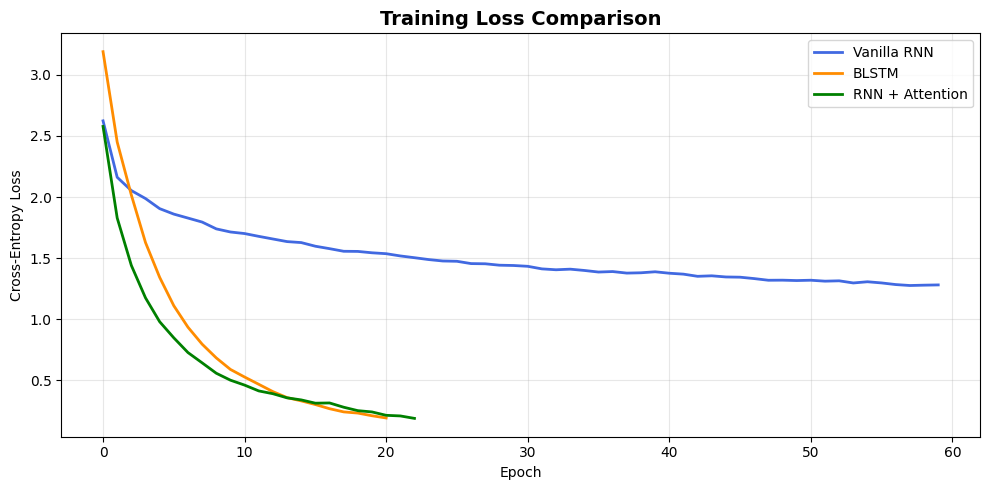

Loss curves saved as training_loss.png


In [11]:
# ============================================================
# Visualize training loss for all three models on one plot.
# Lower loss = better character prediction during training.
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(rnn_loss,   label='Vanilla RNN',      color='royalblue',  linewidth=2)
plt.plot(blstm_loss, label='BLSTM',            color='darkorange', linewidth=2)
plt.plot(attn_loss,  label='RNN + Attention',  color='green',      linewidth=2)

plt.title('Training Loss Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()
print("Loss curves saved as training_loss.png")

In [12]:
# ============================================================
# TASK 2: Quantitative Evaluation
#
# Novelty Rate  = % of generated names NOT in training set
#                 → measures whether the model memorized or generalized
#
# Diversity     = unique generated names / total generated names
#                 → measures variety of outputs
# ============================================================

def evaluate_model(model, model_type, training_names, n_generate=200, temperature=0.8):
    """
    Evaluate a model on Novelty Rate and Diversity.

    Args:
        model          : trained model
        model_type     : 'rnn', 'lstm', or 'attention'
        training_names : set of lowercased training names (for novelty check)
        n_generate     : number of names to generate for evaluation
        temperature    : sampling temperature

    Returns:
        dict with generated names, novelty_rate, diversity
    """
    # Generate names
    generated = generate_names_batch(model, model_type, n=n_generate, temperature=temperature)

    # Filter out empty strings (model may generate nothing sometimes)
    generated = [name for name in generated if len(name) > 0]

    # Training set as lowercase for fair comparison
    train_set = set(n.lower() for n in training_names)

    # Novelty: names not seen in training
    novel = [name for name in generated if name.lower() not in train_set]
    novelty_rate = len(novel) / len(generated) * 100 if generated else 0

    # Diversity: unique names as fraction of total generated
    unique_names = set(name.lower() for name in generated)
    diversity = len(unique_names) / len(generated) * 100 if generated else 0

    return {
        'generated': generated,
        'total': len(generated),
        'novel_count': len(novel),
        'novelty_rate': novelty_rate,
        'unique_count': len(unique_names),
        'diversity': diversity
    }


# Run evaluation for all three models
print("Evaluating all models on 200 generated names each...\n")

rnn_eval   = evaluate_model(rnn_model,   'rnn',       names, n_generate=200)
blstm_eval = evaluate_model(blstm_model, 'lstm',      names, n_generate=200)
attn_eval  = evaluate_model(attn_model,  'attention', names, n_generate=200)

# Print comparison table
print("=" * 62)
print(f"{'Metric':<25} {'Vanilla RNN':>10} {'BLSTM':>10} {'RNN+Attn':>10}")
print("=" * 62)
print(f"{'Total Generated':<25} {rnn_eval['total']:>10} {blstm_eval['total']:>10} {attn_eval['total']:>10}")
print(f"{'Novel Names':<25} {rnn_eval['novel_count']:>10} {blstm_eval['novel_count']:>10} {attn_eval['novel_count']:>10}")
print(f"{'Novelty Rate (%)':<25} {rnn_eval['novelty_rate']:>9.1f}% {blstm_eval['novelty_rate']:>9.1f}% {attn_eval['novelty_rate']:>9.1f}%")
print(f"{'Unique Names':<25} {rnn_eval['unique_count']:>10} {blstm_eval['unique_count']:>10} {attn_eval['unique_count']:>10}")
print(f"{'Diversity (%)':<25} {rnn_eval['diversity']:>9.1f}% {blstm_eval['diversity']:>9.1f}% {attn_eval['diversity']:>9.1f}%")
print("=" * 62)

Evaluating all models on 200 generated names each...

Metric                    Vanilla RNN      BLSTM   RNN+Attn
Total Generated                  200        200        200
Novel Names                      122        200        200
Novelty Rate (%)               61.0%     100.0%     100.0%
Unique Names                     181        188        148
Diversity (%)                  90.5%      94.0%      74.0%


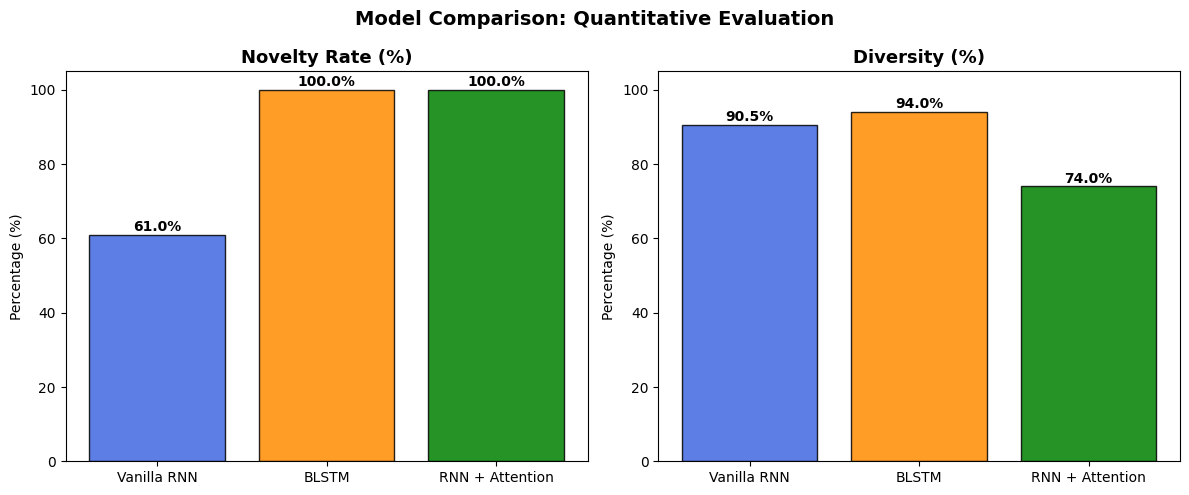

In [13]:
# ============================================================
# Visualize Novelty Rate and Diversity side by side as bar charts
# ============================================================

models = ['Vanilla RNN', 'BLSTM', 'RNN + Attention']
novelty_rates  = [rnn_eval['novelty_rate'],  blstm_eval['novelty_rate'],  attn_eval['novelty_rate']]
diversity_vals = [rnn_eval['diversity'],      blstm_eval['diversity'],      attn_eval['diversity']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['royalblue', 'darkorange', 'green']

# Novelty Rate chart
axes[0].bar(models, novelty_rates, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Novelty Rate (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_ylim(0, 105)
for i, val in enumerate(novelty_rates):
    axes[0].text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')

# Diversity chart
axes[1].bar(models, diversity_vals, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Diversity (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 105)
for i, val in enumerate(diversity_vals):
    axes[1].text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')

plt.suptitle("Model Comparison: Quantitative Evaluation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("quantitative_evaluation.png", dpi=150)
plt.show()

In [14]:
# ============================================================
# TASK 3: Qualitative Analysis
# Generate representative samples for each model and discuss:
#   1. Realism — do names look like real Indian names?
#   2. Failure modes — what goes wrong?
# ============================================================

# Generate 30 sample names per model for display
N_SAMPLES = 30

rnn_samples   = generate_names_batch(rnn_model,   'rnn',       n=N_SAMPLES, temperature=0.8)
blstm_samples = generate_names_batch(blstm_model, 'lstm',      n=N_SAMPLES, temperature=0.8)
attn_samples  = generate_names_batch(attn_model,  'attention', n=N_SAMPLES, temperature=0.8)

print("=" * 60)
print("QUALITATIVE ANALYSIS — Generated Name Samples")
print("=" * 60)

for label, samples in [("Vanilla RNN", rnn_samples),
                        ("BLSTM", blstm_samples),
                        ("RNN + Attention", attn_samples)]:
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    # Print in rows of 6 for readability
    for i in range(0, len(samples), 6):
        print("  " + "  |  ".join(f"{n:<12}" for n in samples[i:i+6]))

# ── Realism heuristic: check if generated names end with common Indian suffixes ──
common_suffixes = ['a', 'i', 'an', 'in', 'ar', 'al', 'sh', 'av', 'ay', 'am']

def realism_score(sample_list):
    """Fraction of names ending with common Indian name suffixes."""
    realistic = sum(1 for n in sample_list if any(n.lower().endswith(s) for s in common_suffixes))
    return realistic / len(sample_list) * 100 if sample_list else 0

print("\n\n" + "=" * 60)
print("Realism Heuristic (% names ending with common Indian suffixes)")
print("=" * 60)
for label, samples in [("Vanilla RNN", rnn_samples),
                        ("BLSTM", blstm_samples),
                        ("RNN + Attention", attn_samples)]:
    print(f"  {label:<20}: {realism_score(samples):.1f}%")


QUALITATIVE ANALYSIS — Generated Name Samples

────────────────────────────────────────
  Vanilla RNN
────────────────────────────────────────
  Banila        |  Gitakant      |  Prathik       |  Sarmit        |  Aryansh       |  Ritavati    
  Kalawrti      |  Aryan         |  Jagdevi       |  Aryaben       |  Anilpan       |  Ishita      
  Anaguksh      |  Kalali        |  Karthi        |  Rajan8        |  Aryapriyu     |  Abhijeth    
  Kalaben       |  Anariyesh     |  Amisha        |  Amol          |  Shanthi       |  Amiya       
  Anirudh       |  Aryaben       |  Vedawati      |  Priyawati     |  Anirudh       |  Balaji      

────────────────────────────────────────
  BLSTM
────────────────────────────────────────
  Ngn1agalili   |  Fkhehedadar   |  Mymojon       |  Fyepepararwdwd  |  Gagalili      |  Lalamimip   
  Jkjenend      |  Gagalili      |  Jujun19wyayaw  |  Tutusrsr      |  Ugug          |  Qagalelenini
  Sasa          |  Galalumumi    |  Vavatetebi    |  Giginanale

In [15]:
# ============================================================
# Final summary: architecture comparison for the report
# ============================================================

print("=" * 70)
print(f"{'Model':<22} {'Embed':>6} {'Hidden':>8} {'Layers':>7} {'Params':>12}")
print("=" * 70)

for model, name, embed, hidden, layers in [
    (rnn_model,   'Vanilla RNN',     64, 256, 2),
    (blstm_model, 'BLSTM',           64, '128x2', 2),
    (attn_model,  'RNN + Attention', 64, 256, 2),
]:
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {name:<20} {str(embed):>6} {str(hidden):>8} {layers:>7} {n_params:>12,}")

print("=" * 70)
print("\nAll outputs saved: training_loss.png, quantitative_evaluation.png")
print("Model training complete. Ready for report writing.")

Model                   Embed   Hidden  Layers       Params
  Vanilla RNN              64      256       2      226,535
  BLSTM                    64    128x2       2       56,455
  RNN + Attention          64      256       2    1,162,151

All outputs saved: training_loss.png, quantitative_evaluation.png
Model training complete. Ready for report writing.
